# Task 2: Exploratory Data Analysis (EDA)

## Objective

The objective of this task is to analyze the Superstore Sales dataset using descriptive statistics and visualizations to identify trends, patterns, and business insights.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

plt.rcParams['figure.figsize']=(10,6)

In [4]:
df=pd.read_csv("../Task1 - Data Cleaning/Cleaned_Superstore.csv")

In [5]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9800 non-null   int64  
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [8]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9800.000000,9800.000000
mean,4900.500000,55217.343265,230.769059
std,2829.160653,32066.750532,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,57551.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [9]:
df.corr(numeric_only=True)

,Row ID,Postal Code,Sales
Row ID,1.000000,0.011527,0.001151
Postal Code,0.011527,1.000000,-0.025588
Sales,0.001151,-0.025588,1.000000


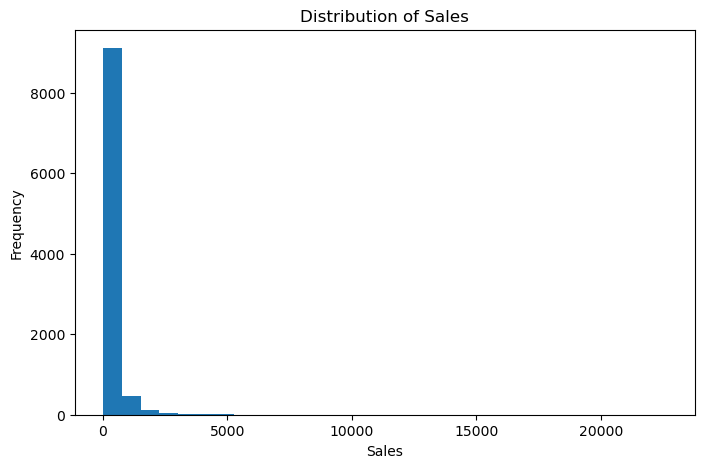

In [10]:
plt.figure(figsize=(8,5))
plt.hist(df['Sales'],bins=30)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

## Observation
Most sales are of smaller amounts, while a few transactions have very high sales, indicating a right-skewed distribution.

# Category Sales

The category-wise analysis shows differences in sales contribution across Furniture, Office Supplies, and Technology. This indicates that product category has an important influence on overall sales performance.

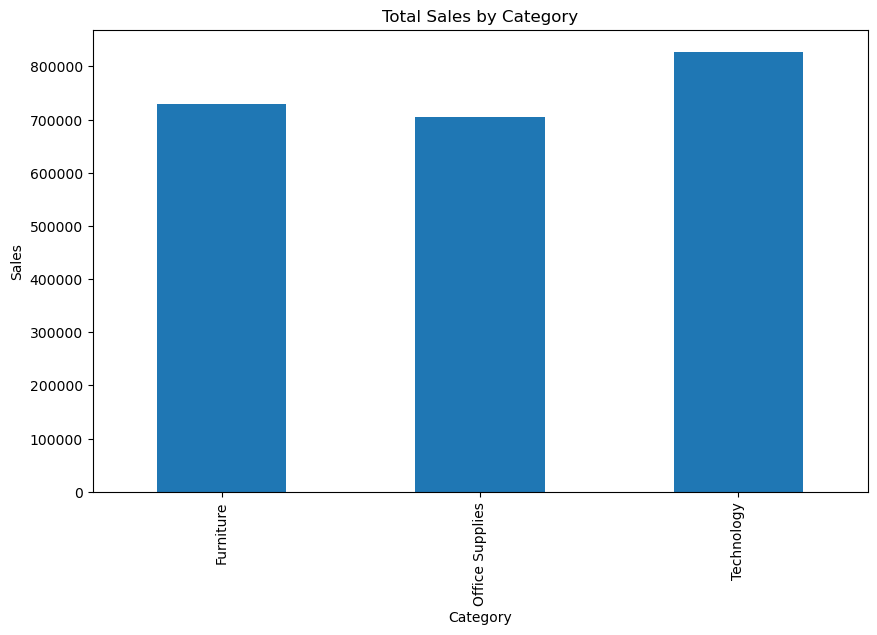

In [12]:
category_sales=df.groupby('Category')["Sales"].sum()
category_sales.plot(kind='bar')
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

# Regional Sales

Sales vary across regions, indicating that geographic location may influence business performance.

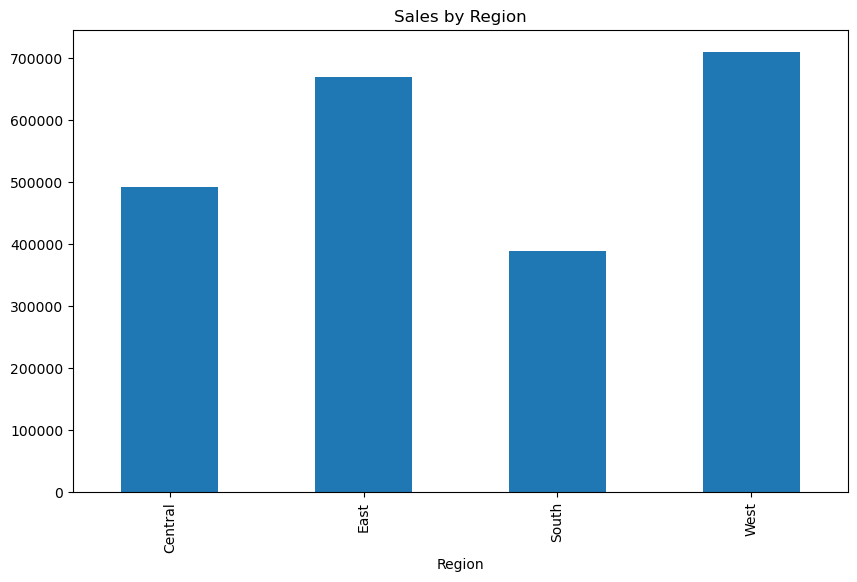

In [6]:
region_sales = df.groupby("Region")["Sales"].sum()
region_sales.plot(kind="bar")
plt.title("Sales by Region")
plt.show()

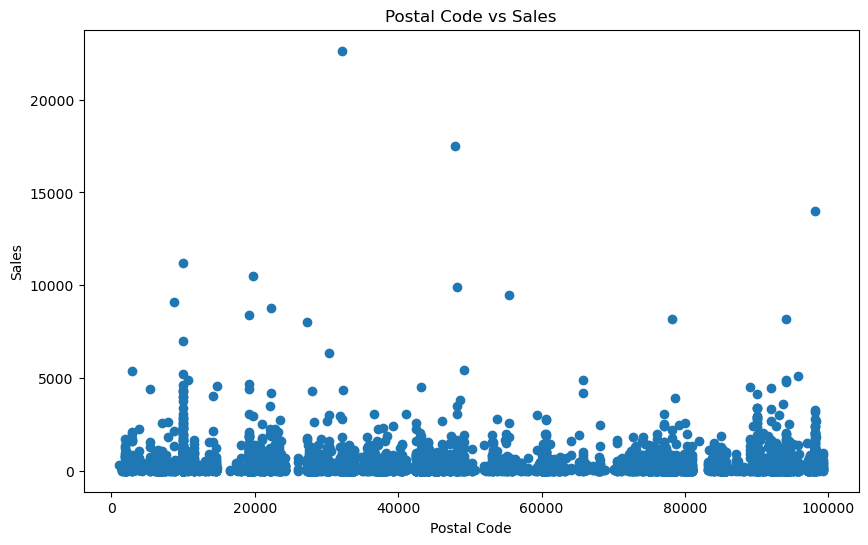

In [7]:
plt.scatter(df["Postal Code"], df["Sales"])
plt.title("Postal Code vs Sales")
plt.xlabel("Postal Code")
plt.ylabel("Sales")
plt.show()

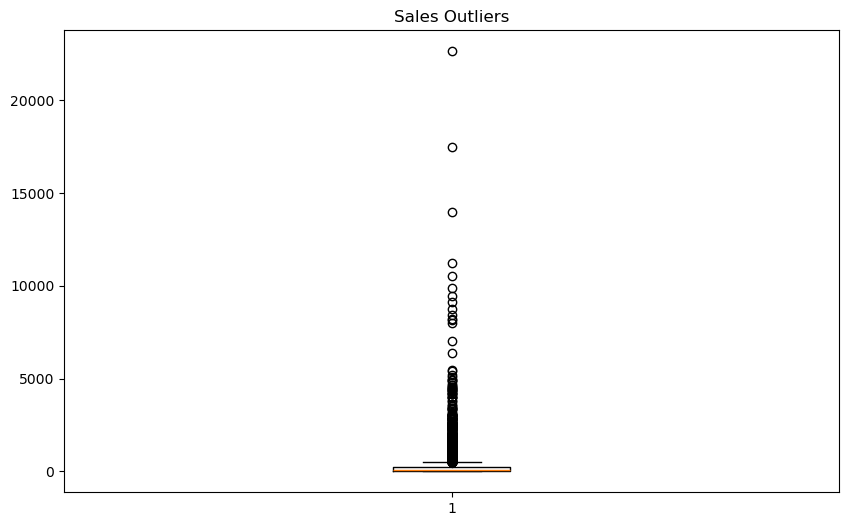

In [8]:
plt.boxplot(df["Sales"])
plt.title("Sales Outliers")
plt.show()

## Observation
The box plot shows several high-value outliers in sales.

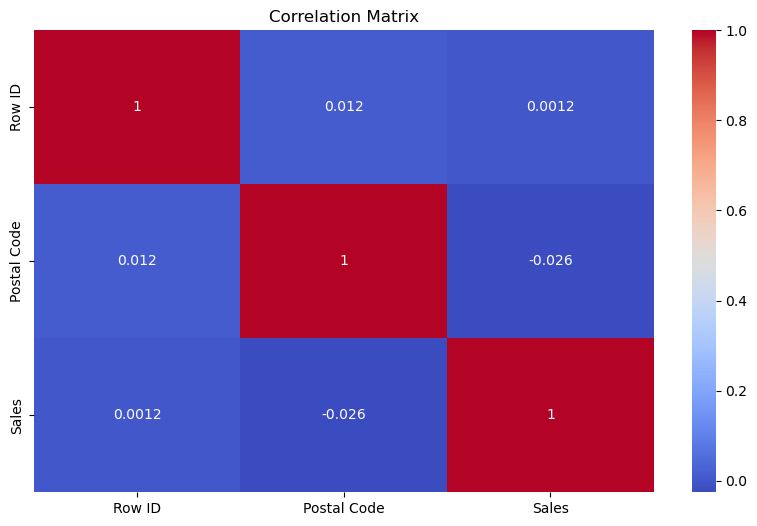

In [9]:
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

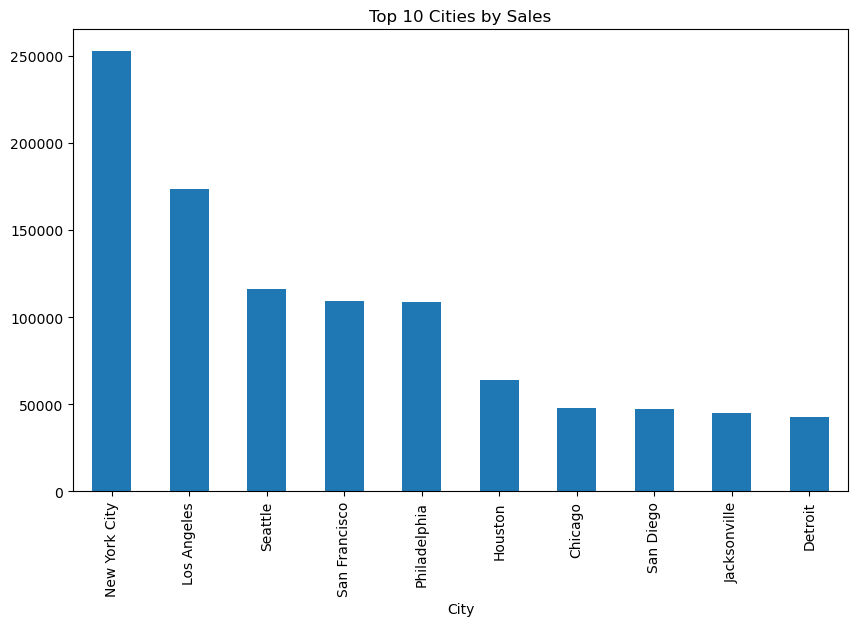

In [10]:
top_cities = df.groupby("City")["Sales"].sum().sort_values(ascending=False).head(10)
top_cities.plot(kind="bar")
plt.title("Top 10 Cities by Sales")
plt.show()

In [11]:
df["Category"].value_counts()

Category
Office Supplies    5909
Furniture          2078
Technology         1813
Name: count, dtype: int64

In [13]:
df["Segment"].value_counts()

Segment
Consumer       5101
Corporate      2953
Home Office    1746
Name: count, dtype: int64

In [14]:
df["Region"].value_counts()

Region
West       3140
East       2785
Central    2277
South      1598
Name: count, dtype: int64

## Key Findings
1. Technology contributes the highest sales.
2. The sales distribution is highly right-skewed.
3. High-value sales transactions appear as outliers.
4. Sales vary significantly across different regions.
5. A small number of cities contribute a large share of total sales.

In [17]:
plt.savefig("images/sales_distribution.png", dpi=300, bbox_inches="tight")

<Figure size 1000x600 with 0 Axes>

In [19]:
plt.savefig("images/category_sales.png", dpi=300, bbox_inches="tight")

<Figure size 1000x600 with 0 Axes>

In [20]:
plt.savefig("images/region_sales.png", dpi=300, bbox_inches="tight")

<Figure size 1000x600 with 0 Axes>

In [21]:
plt.savefig("images/sales_boxplot.png", dpi=300, bbox_inches="tight")

<Figure size 1000x600 with 0 Axes>

In [22]:
plt.savefig("images/correlation_heatmap.png", dpi=300, bbox_inches="tight")

<Figure size 1000x600 with 0 Axes>

In [23]:
plt.savefig("images/top_cities.png", dpi=300, bbox_inches="tight")

<Figure size 1000x600 with 0 Axes>

## Conclusion

Exploratory Data Analysis was performed on the cleaned Superstore dataset using Pandas, Matplotlib, and Seaborn. Various visualizations were created to understand sales distributions, category performance, regional trends, and potential outliers.

The analysis helped identify important patterns in the dataset and provided a better understanding of the factors affecting sales performance. These findings can be used as a foundation for further data analysis and machine learning tasks.